In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Superstore_raw.csv", encoding='latin1')

In [ ]:
# Display the first 5 rows
df.head ()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check dataset shape
df.shape

(9994, 21)

In [ ]:
# Check column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [ ]:
# Check data types
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
# Extract date components
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = df["Order Date"].dt.quarter

In [ ]:
# Calculate shipping duration
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [ ]:
# Calculate profit margin
df["Profit Margin"] = df["Profit"] / df["Sales"]

In [ ]:
# Checking the analytical columns
df[
    [
        "Order Date",
        "Order Year",
        "Order Month Name",
        "Order Quarter",
        "Shipping Days",
        "Sales",
        "Profit",
        "Profit Margin"
    ]
].head()

,Order Date,Order Year,Order Month Name,Order Quarter,Shipping Days,Sales,Profit,Profit Margin
0,2016-11-08,2016,November,4,3,261.9600,41.9136,0.1600
1,2016-11-08,2016,November,4,3,731.9400,219.5820,0.3000
2,2016-06-12,2016,June,2,4,14.6200,6.8714,0.4700
3,2015-10-11,2015,October,4,7,957.5775,-383.0310,-0.4000
4,2015-10-11,2015,October,4,7,22.3680,2.5164,0.1125


In [ ]:
# Check the new columns (min, max, mean, sd)
df[
    [
        "Order Year",
        "Order Month Name",
        "Order Quarter",
        "Shipping Days",
        "Profit Margin"
    ]
].describe()

,Order Year,Order Quarter,Shipping Days,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,2015.722233,2.882329,3.958175,0.120314
std,1.123555,1.058086,1.747567,0.466754
min,2014.000000,1.000000,0.000000,-2.750000
25%,2015.000000,2.000000,3.000000,0.075000
50%,2016.000000,3.000000,4.000000,0.270000
75%,2017.000000,4.000000,5.000000,0.362500
max,2017.000000,4.000000,7.000000,0.500000


In [ ]:
# Check for missing values in our new columns
df[
    [
        "Order Year",
        "Order Month Name",
        "Order Quarter",
        "Shipping Days",
        "Profit Margin"
    ]
].isnull().sum()

,0
Order Year,0
Order Month Name,0
Order Quarter,0
Shipping Days,0
Profit Margin,0


In [ ]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
# Check the new column names
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub-category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'order_year',
 'order_month',
 'order_month_name',
 'order_quarter',
 'shipping_days',
 'profit_margin']

In [ ]:
# Rows, columns total count
df.shape

(9994, 27)

In [ ]:
# Checking datatype
df.dtypes

,0
row_id,int64
order_id,object
order_date,datetime64[ns]
ship_date,datetime64[ns]
ship_mode,object
customer_id,object
customer_name,object
segment,object
country,object
city,object


In [ ]:
# Renaming the column
df = df.rename(columns={
    "sub-category": "sub_category"
})


In [ ]:
# Column list
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'postal_code',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'order_year',
 'order_month',
 'order_month_name',
 'order_quarter',
 'shipping_days',
 'profit_margin']

In [ ]:
# Describe
df[["sales", "quantity", "discount", "profit", "profit_margin"]].describe()

,sales,quantity,discount,profit,profit_margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,0.120314
std,623.245101,2.225110,0.206452,234.260108,0.466754
min,0.444000,1.000000,0.000000,-6599.978000,-2.750000
25%,17.280000,2.000000,0.000000,1.728750,0.075000
50%,54.490000,3.000000,0.200000,8.666500,0.270000
75%,209.940000,5.000000,0.200000,29.364000,0.362500
max,22638.480000,14.000000,0.800000,8399.976000,0.500000


In [ ]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

# Check for invalid shipping days
print("Negative shipping days:", (df["shipping_days"] < 0).sum())

# Check for invalid discounts
print("Invalid discounts:", ((df["discount"] < 0) | (df["discount"] > 1)).sum())

# Check for invalid sales
print("Non-positive sales:", (df["sales"] <= 0).sum())

Duplicate rows: 0
Total missing values: 0
Negative shipping days: 0
Invalid discounts: 0
Non-positive sales: 0


In [ ]:
# Core business KPIs

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_products = df["product_id"].nunique()
average_order_value = total_sales / total_orders
overall_profit_margin = total_profit / total_sales

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Average Order Value:", round(average_order_value, 2))
print("Overall Profit Margin:", round(overall_profit_margin * 100, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Total Products: 1862
Average Order Value: 458.61
Overall Profit Margin: 12.47 %


In [ ]:
# Sales and profit by year

yearly_performance = (
    df.groupby("order_year")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
)

yearly_performance["profit_margin"] = (
    yearly_performance["profit"] /
    yearly_performance["sales"]
)

yearly_performance

,order_year,sales,profit,orders,profit_margin
0,2014,484247.4981,49543.9741,969,0.102311
1,2015,470532.5090,61618.6037,1038,0.130955
2,2016,609205.5980,81795.1743,1315,0.134265
3,2017,733215.2552,93439.2696,1687,0.127438


In [ ]:
# Monthly sales and profit

monthly_performance = (
    df.groupby(["order_year", "order_month", "order_month_name"])
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
      .sort_values(["order_year", "order_month"])
)

monthly_performance.head(12)

,order_year,order_month,order_month_name,sales,profit
0,2014,1,January,14236.8950,2450.1907
1,2014,2,February,4519.8920,862.3084
2,2014,3,March,55691.0090,498.7299
3,2014,4,April,28295.3450,3488.8352
4,2014,5,May,23648.2870,2738.7096
5,2014,6,June,34595.1276,4976.5244
6,2014,7,July,33946.3930,-841.4826
7,2014,8,August,27909.4685,5318.1050
8,2014,9,September,81777.3508,8328.0994
9,2014,10,October,31453.3930,3448.2573


In [ ]:
# Highest sales months
top_sales_months = (
    monthly_performance
    .sort_values("sales", ascending=False)
    .head(5)
)

print("Top 5 Sales Months:")
top_sales_months

Top 5 Sales Months:


,order_year,order_month,order_month_name,sales,profit
46,2017,11,November,118447.8250,9690.1037
35,2016,12,December,96999.0430,17885.3093
44,2017,9,September,87866.6520,10991.5556
47,2017,12,December,83829.3188,8483.3468
8,2014,9,September,81777.3508,8328.0994


In [ ]:
# Lowest sales months
bottom_sales_months = (
    monthly_performance
    .sort_values("sales")
    .head(5)
)

print("Bottom 5 Sales Months:")
bottom_sales_months

Bottom 5 Sales Months:


,order_year,order_month,order_month_name,sales,profit
1,2014,2,February,4519.8920,862.3084
13,2015,2,February,11951.4110,2813.8508
0,2014,1,January,14236.8950,2450.1907
12,2015,1,January,18174.0756,-3281.0070
24,2016,1,January,18542.4910,2824.8233


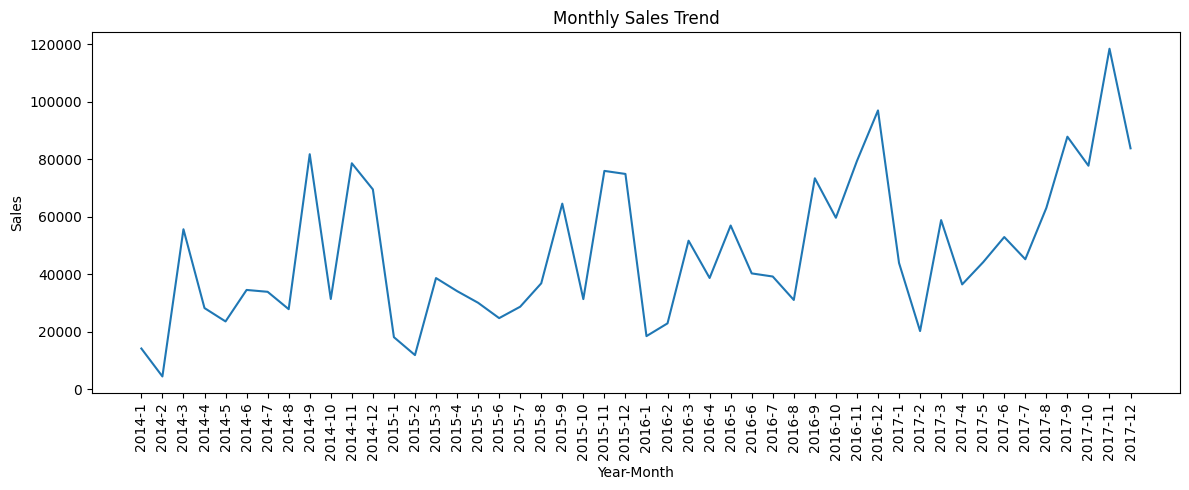

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["order_year"].astype(str) + "-" +
    monthly_performance["order_month"].astype(str),
    monthly_performance["sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [ ]:
# Sales and profit by category

category_performance = (
    df.groupby("category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

category_performance["profit_margin"] = (
    category_performance["profit"] /
    category_performance["sales"]
)

category_performance.sort_values(
    "sales",
    ascending=False
)

,category,sales,profit,orders,quantity,profit_margin
2,Technology,836154.0330,145454.9481,1544,6939,0.173957
0,Furniture,741999.7953,18451.2728,1764,8028,0.024867
1,Office Supplies,719047.0320,122490.8008,3742,22906,0.170352


In [ ]:
# Furniture performance by sub-category

furniture_performance = (
    df[df["category"] == "Furniture"]
    .groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

furniture_performance["profit_margin"] = (
    furniture_performance["profit"] /
    furniture_performance["sales"]
)

furniture_performance.sort_values(
    "profit",
    ascending=True
)

,sub_category,sales,profit,orders,quantity,profit_margin
3,Tables,206965.5320,-17725.4811,307,1241,-0.085645
0,Bookcases,114879.9963,-3472.5560,224,868,-0.030228
2,Furnishings,91705.1640,13059.1436,877,3563,0.142404
1,Chairs,328449.1030,26590.1663,576,2356,0.080957


In [ ]:
# Analyze discount and profitability

discount_analysis = (
    df.groupby("discount")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
)

discount_analysis["profit_margin"] = (
    discount_analysis["profit"] /
    discount_analysis["sales"]
)

discount_analysis.sort_values("discount")

,discount,sales,profit,orders,profit_margin
0,0.00,1.087908e+06,320987.6032,2644,0.295050
1,0.10,5.436935e+04,9029.1770,89,0.166071
2,0.15,2.755852e+04,1418.9915,51,0.051490
3,0.20,7.645944e+05,90337.3060,2407,0.118151
4,0.30,1.032267e+05,-10369.2774,211,-0.100452
5,0.32,1.449346e+04,-2391.1377,27,-0.164980
6,0.40,1.164178e+05,-23057.0504,185,-0.198054
7,0.45,5.484974e+03,-2493.1111,10,-0.454535
8,0.50,5.891854e+04,-20506.4281,64,-0.348047
9,0.60,6.644700e+03,-5944.6552,127,-0.894646


In [ ]:
# Discount and profitability within Furniture

furniture_discount = (
    df[df["category"] == "Furniture"]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

furniture_discount["profit_margin"] = (
    furniture_discount["profit"] /
    furniture_discount["sales"]
)
furniture_discount.sort_values("discount")

,discount,sales,profit,orders,profit_margin
0,0.00,256025.2700,58133.0764,739,0.227060
1,0.10,46634.2470,7111.0119,71,0.152485
2,0.15,27558.5215,1418.9915,51,0.051490
3,0.20,216631.0160,6265.9491,539,0.028925
4,0.30,99470.3500,-10695.3169,207,-0.107523
5,0.32,14493.4588,-2391.1377,27,-0.164980
6,0.40,45614.4060,-16187.3968,72,-0.354875
7,0.45,5484.9740,-2493.1111,10,-0.454535
8,0.50,20983.4700,-12871.1990,53,-0.613397
9,0.60,6644.7000,-5944.6552,127,-0.894646


In [ ]:
# Furniture sub-category and discount analysis

furniture_sub_discount = (
    df[df["category"] == "Furniture"]
    .groupby(["sub_category", "discount"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

furniture_sub_discount["profit_margin"] = (
    furniture_sub_discount["profit"] /
    furniture_sub_discount["sales"]
)

furniture_sub_discount.sort_values(
    ["sub_category", "discount"]
)

,sub_category,discount,sales,profit,orders,profit_margin
0,Bookcases,0.00,31935.9800,6075.7117,60,0.190247
1,Bookcases,0.15,27558.5215,1418.9915,51,0.051490
2,Bookcases,0.20,26841.4960,130.5022,44,0.004862
3,Bookcases,0.30,4282.6980,-555.8726,9,-0.129795
4,Bookcases,0.32,14493.4588,-2391.1377,27,-0.164980
5,Bookcases,0.50,7308.4600,-4255.8117,18,-0.582313
6,Bookcases,0.70,2459.3820,-3894.9394,15,-1.583707
7,Chairs,0.00,91060.7300,21933.0961,124,0.240862
8,Chairs,0.10,46634.2470,7111.0119,71,0.152485
9,Chairs,0.20,120748.6240,4283.1750,232,0.035472


In [ ]:
# Loss-making products in Tables

tables_products = (
    df[
        (df["category"] == "Furniture") &
        (df["sub_category"] == "Tables")
    ]
    .groupby(["product_id", "product_name"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

tables_products["profit_margin"] = (
    tables_products["profit"] /
    tables_products["sales"]
)

tables_products.sort_values(
    "profit",
    ascending=True
).head(10)

,product_id,product_name,sales,profit,quantity,orders,profit_margin
0,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2876.1156,27,5,-0.290000
18,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.7250,-1934.3976,33,7,-0.202667
20,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.7540,-1201.0581,19,4,-0.184247
49,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.2500,-1148.4375,15,3,-0.673077
46,FUR-TA-10004154,"Riverside Furniture Oval Coffee Table, Oval En...",4446.1750,-1147.4000,25,5,-0.258065
48,FUR-TA-10004256,Bretford Just In Time Height-Adjustable Mult...,5634.9000,-964.1940,17,4,-0.171111
32,FUR-TA-10002958,"Bevis Oval Conference Table, Walnut",6942.0680,-856.0144,36,8,-0.123308
25,FUR-TA-10002533,BPI Conference Tables,2241.8675,-795.9725,26,5,-0.355049
42,FUR-TA-10003954,Hon 94000 Series Round Tables,7404.5000,-681.2140,30,5,-0.092000
34,FUR-TA-10003238,"Chromcraft Bull-Nose Wood 48"" x 96"" Rectangula...",4297.6440,-611.5878,11,6,-0.142308


In [ ]:
# Find the biggest loss-making Table product
worst_table_product = tables_products.sort_values(
    "profit",
    ascending=True
).iloc[0]

worst_table_product

,0
product_id,FUR-TA-10000198
product_name,Chromcraft Bull-Nose Wood Oval Conference Tabl...
sales,9917.64
profit,-2876.1156
quantity,27
orders,5
profit_margin,-0.29


In [ ]:
# View all transactions for the biggest loss-making product

product_id = worst_table_product["product_id"]

df[
    df["product_id"] == product_id
][
    [
        "order_date",
        "order_id",
        "customer_name",
        "region",
        "sales",
        "quantity",
        "discount",
        "profit",
        "profit_margin"
    ]
].sort_values("order_date")

,order_date,order_id,customer_name,region,sales,quantity,discount,profit,profit_margin
9899,2014-03-28,US-2014-117380,Mike Pelletier,East,330.588,1,0.4,-143.2548,-0.433333
9639,2015-01-28,CA-2015-116638,Joseph Holt,South,4297.644,13,0.4,-1862.3124,-0.433333
721,2016-12-15,CA-2016-142335,Michael Paige,Central,1652.940,3,0.0,231.4116,0.140000
2477,2017-09-04,CA-2017-102750,Greg Maxwell,West,1322.352,3,0.2,-99.1764,-0.075000
5320,2017-10-02,US-2017-162558,Dean percer,South,2314.116,7,0.4,-1002.7836,-0.433333


In [ ]:
# Regional performance

regional_performance = (
    df.groupby("region")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

regional_performance["profit_margin"] = (
    regional_performance["profit"] /
    regional_performance["sales"]
)

regional_performance.sort_values(
    "profit",
    ascending=False
)

,region,sales,profit,orders,customers,profit_margin
3,West,725457.8245,108418.4489,1611,686,0.149448
1,East,678781.2400,91522.7800,1401,674,0.134834
2,South,391721.9050,46749.4303,822,512,0.119343
0,Central,501239.8908,39706.3625,1175,629,0.079216


In [ ]:
# Category performance within Central region

central_category = (
    df[df["region"] == "Central"]
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

central_category["profit_margin"] = (
    central_category["profit"] /
    central_category["sales"]
)

central_category.sort_values("profit_margin")

,category,sales,profit,orders,profit_margin
0,Furniture,163797.1638,-2871.0494,403,-0.017528
1,Office Supplies,167026.4150,8879.9799,880,0.053165
2,Technology,170416.3120,33697.4320,356,0.197736


In [ ]:
# Central Furniture sub-category performance

central_furniture = (
    df[
        (df["region"] == "Central") &
        (df["category"] == "Furniture")
    ]
    .groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

central_furniture["profit_margin"] = (
    central_furniture["profit"] /
    central_furniture["sales"]
)

central_furniture.sort_values("profit", ascending=True)

,sub_category,sales,profit,orders,profit_margin
2,Furnishings,15254.3700,-3906.2168,191,-0.256072
3,Tables,39154.9710,-3559.6504,68,-0.090912
0,Bookcases,24157.1768,-1997.9043,49,-0.082704
1,Chairs,85230.6460,6592.7221,144,0.077352


In [ ]:
# Central Furniture: discount vs profitability

central_furniture_discount = (
    df[
        (df["region"] == "Central") &
        (df["category"] == "Furniture")
    ]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

central_furniture_discount["profit_margin"] = (
    central_furniture_discount["profit"] /
    central_furniture_discount["sales"]
)

central_furniture_discount.sort_values("discount")

,discount,sales,profit,orders,profit_margin
0,0.00,74929.3500,16641.3819,130,0.222094
1,0.30,61178.9850,-6866.8937,133,-0.112243
2,0.32,14493.4588,-2391.1377,27,-0.164980
3,0.50,6550.6700,-4309.7447,17,-0.657909
4,0.60,6644.7000,-5944.6552,127,-0.894646


In [ ]:
# Customer segment performance

segment_performance = (
    df.groupby("segment")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

segment_performance["profit_margin"] = (
    segment_performance["profit"] /
    segment_performance["sales"]
)

segment_performance.sort_values(
    "sales",
    ascending=False
)

,segment,sales,profit,orders,customers,profit_margin
0,Consumer,1.161401e+06,134119.2092,2586,409,0.115481
1,Corporate,7.061464e+05,91979.1340,1514,236,0.130255
2,Home Office,4.296531e+05,60298.6785,909,148,0.140343


In [ ]:
# Sales per Customer and Profit per Customer.
segment_performance["sales_per_customer"] = (
    segment_performance["sales"] /
    segment_performance["customers"]
)

segment_performance["profit_per_customer"] = (
    segment_performance["profit"] /
    segment_performance["customers"]
)

segment_performance.sort_values(
    "profit_per_customer",
    ascending=False
)

,segment,sales,profit,orders,customers,profit_margin,sales_per_customer,profit_per_customer
2,Home Office,4.296531e+05,60298.6785,909,148,0.140343,2903.061814,407.423503
1,Corporate,7.061464e+05,91979.1340,1514,236,0.130255,2992.145622,389.742093
0,Consumer,1.161401e+06,134119.2092,2586,409,0.115481,2839.612090,327.919827


In [ ]:
# Orders per customer

customer_orders = (
    df.groupby("customer_id")
      .agg(
          customer_name=("customer_name", "first"),
          orders=("order_id", "nunique"),
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

customer_orders["profit_margin"] = (
    customer_orders["profit"] /
    customer_orders["sales"]
)

customer_orders.head()

,customer_id,customer_name,orders,sales,profit,profit_margin
0,AA-10315,Alex Avila,5,5563.560,-362.8825,-0.065225
1,AA-10375,Allen Armold,9,1056.390,277.3824,0.262576
2,AA-10480,Andrew Allen,4,1790.512,435.8274,0.243409
3,AA-10645,Anna Andreadi,6,5086.935,857.8033,0.168629
4,AB-10015,Aaron Bergman,3,886.156,129.3465,0.145964


In [ ]:
# Classify customers by order frequency

customer_orders["customer_type"] = customer_orders["orders"].apply(
    lambda x: "One-time" if x == 1 else "Repeat"
)

customer_type_analysis = (
    customer_orders
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        average_orders=("orders", "mean")
    )
    .reset_index()
)

customer_type_analysis["profit_margin"] = (
    customer_type_analysis["profit"] /
    customer_type_analysis["sales"]
)

customer_type_analysis["sales_per_customer"] = (
    customer_type_analysis["sales"] /
    customer_type_analysis["customers"]
)

customer_type_analysis["profit_per_customer"] = (
    customer_type_analysis["profit"] /
    customer_type_analysis["customers"]
)

customer_type_analysis

,customer_type,customers,sales,profit,average_orders,profit_margin,sales_per_customer,profit_per_customer
0,One-time,12,5.167640e+03,767.3746,1.000000,0.148496,430.636667,63.947883
1,Repeat,781,2.292033e+06,285629.6471,6.398207,0.124618,2934.741639,365.722980


In [ ]:
# Top 10 customers by sales

top_customers = (
    customer_orders
    .sort_values("sales", ascending=False)
    .head(10)
)

top_customers[
    [
        "customer_id",
        "customer_name",
        "orders",
        "sales",
        "profit",
        "profit_margin"
    ]
]

,customer_id,customer_name,orders,sales,profit,profit_margin
700,SM-20320,Sean Miller,5,25043.050,-1980.7393,-0.079093
741,TC-20980,Tamara Chand,5,19052.218,8981.3239,0.471406
621,RB-19360,Raymond Buch,6,15117.339,6976.0959,0.461463
730,TA-21385,Tom Ashbrook,4,14595.620,4703.7883,0.322274
6,AB-10105,Adrian Barton,10,14473.571,5444.8055,0.376190
434,KL-16645,Ken Lonsdale,12,14175.229,806.8550,0.056920
669,SC-20095,Sanjit Chand,9,14142.334,5757.4119,0.407105
327,HL-15040,Hunter Lopez,6,12873.298,5622.4292,0.436751
683,SE-20110,Sanjit Engle,11,12209.438,2650.6769,0.217101
131,CC-12370,Christopher Conant,5,12129.072,2177.0493,0.179490


In [ ]:
# Top 10 loss-making customers

loss_making_customers = (
    customer_orders
    .sort_values("profit", ascending=True)
    .head(10)
)

loss_making_customers[
    [
        "customer_id",
        "customer_name",
        "orders",
        "sales",
        "profit",
        "profit_margin"
    ]
]

,customer_id,customer_name,orders,sales,profit,profit_margin
180,CS-12505,Cindy Stewart,6,5690.055,-6626.3895,-1.164556
310,GT-14635,Grant Thornton,3,9351.212,-4108.6589,-0.439372
459,LF-17185,Luke Foster,7,3930.509,-3583.9770,-0.911835
711,SR-20425,Sharelle Roach,5,3233.481,-3333.9144,-1.031060
322,HG-14965,Henry Goldwyn,12,3247.642,-2797.9635,-0.861537
555,NC-18415,Nathan Cano,6,2218.990,-2204.8072,-0.993608
666,SB-20290,Sean Braxton,7,8057.891,-2082.7451,-0.258473
700,SM-20320,Sean Miller,5,25043.050,-1980.7393,-0.079093
165,CP-12340,Christine Phan,8,5888.275,-1850.3029,-0.314235
560,NF-18385,Natalie Fritzler,7,8322.826,-1695.9714,-0.203774


In [ ]:
#Reconcile customer count

print("Overall unique customers:", df["customer_id"].nunique())
print("Customer orders table:", customer_orders["customer_id"].nunique())

print("\nCustomers with missing customer_id:")
print(df["customer_id"].isna().sum())

print("\nCustomer types:")
print(customer_orders["customer_type"].value_counts())

Overall unique customers: 793
Customer orders table: 793

Customers with missing customer_id:
0

Customer types:
customer_type
Repeat      781
One-time     12
Name: count, dtype: int64


In [ ]:
# Top 10 customers by profit

top_profit_customers = (
    customer_orders
    .sort_values("profit", ascending=False)
    .head(10)
)

top_profit_customers[
    [
        "customer_id",
        "customer_name",
        "orders",
        "sales",
        "profit",
        "profit_margin"
    ]
]

,customer_id,customer_name,orders,sales,profit,profit_margin
741,TC-20980,Tamara Chand,5,19052.218,8981.3239,0.471406
621,RB-19360,Raymond Buch,6,15117.339,6976.0959,0.461463
669,SC-20095,Sanjit Chand,9,14142.334,5757.4119,0.407105
327,HL-15040,Hunter Lopez,6,12873.298,5622.4292,0.436751
6,AB-10105,Adrian Barton,10,14473.571,5444.8055,0.376190
730,TA-21385,Tom Ashbrook,4,14595.620,4703.7883,0.322274
160,CM-12385,Christopher Martinez,4,8954.020,3899.8904,0.435546
424,KD-16495,Keith Dawkins,12,8181.256,3038.6254,0.371413
48,AR-10540,Andy Reiter,6,6608.448,2884.6208,0.436505
234,DR-12940,Daniel Raglin,8,8350.868,2869.0760,0.343566


In [ ]:
# Overall sub-category performance

subcategory_performance = (
    df.groupby("sub_category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

subcategory_performance["profit_margin"] = (
    subcategory_performance["profit"] /
    subcategory_performance["sales"]
)

subcategory_performance.sort_values(
    "sales",
    ascending=False
)

,sub_category,sales,profit,orders,quantity,profit_margin
13,Phones,330007.0540,44515.7306,814,3289,0.134893
5,Chairs,328449.1030,26590.1663,576,2356,0.080957
14,Storage,223843.6080,21278.8264,777,3158,0.095061
16,Tables,206965.5320,-17725.4811,307,1241,-0.085645
3,Binders,203412.7330,30221.7633,1316,5974,0.148574
11,Machines,189238.6310,3384.7569,112,440,0.017886
0,Accessories,167380.3180,41936.6357,718,2976,0.250547
6,Copiers,149528.0300,55617.8249,68,234,0.371956
4,Bookcases,114879.9963,-3472.5560,224,868,-0.030228
1,Appliances,107532.1610,18138.0054,451,1729,0.168675


In [ ]:
# Top 10 products by profit

product_performance = (
    df.groupby(["product_id", "product_name"])
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          quantity=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .reset_index()
)

product_performance["profit_margin"] = (
    product_performance["profit"] /
    product_performance["sales"]
)

top_profit_products = (
    product_performance
    .sort_values("profit", ascending=False)
    .head(10)
)

top_profit_products

,product_id,product_name,sales,profit,quantity,orders,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.409091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.282407
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.370701
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.393373
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.222857
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,0.490000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,0.260000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,0.394595
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,0.210714
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,0.480000


In [ ]:
# Top 10 products by loss

loss_products = (
    product_performance
    .sort_values("profit", ascending=True)
    .head(10)
)

loss_products

,product_id,product_name,sales,profit,quantity,orders,profit_margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,-0.800000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,-0.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,-0.480000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,5,-0.290000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,7,-0.202667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6,-0.104545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6,1,-0.080000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22,6,-0.078000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4,-0.184247
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15,3,-0.673077


In [ ]:
# Cubify analysis
cubify_analysis = (
    df[
        df["product_name"].str.contains("Cubify", case=False, na=False)
    ]
    .groupby(["product_id", "product_name"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

cubify_analysis["profit_margin"] = (
    cubify_analysis["profit"] /
    cubify_analysis["sales"]
)

cubify_analysis

,product_id,product_name,sales,profit,quantity,orders,avg_discount,profit_margin
0,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,0.533333,-0.80
1,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,0.500000,-0.48


In [ ]:
#Shipping Analysis
shipping_analysis = (
    df.groupby("shipping_days")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

shipping_analysis["profit_margin"] = (
    shipping_analysis["profit"] /
    shipping_analysis["sales"]
)

shipping_analysis.sort_values("shipping_days")

,shipping_days,sales,profit,orders,quantity,profit_margin
0,0,124907.6910,15385.9685,252,1864,0.123179
1,1,67975.3312,7541.2269,182,1384,0.110941
2,2,368465.8300,53118.1143,675,4989,0.144160
3,3,204659.5988,26875.9187,509,3811,0.131320
4,4,631847.0053,71134.7742,1403,10665,0.112582
5,5,494357.0837,58733.2045,1084,8205,0.118807
6,6,240290.5698,33275.9677,596,4546,0.138482
7,7,164697.7505,20331.8469,308,2409,0.123449


In [ ]:
# State-level performance

state_performance = (
    df.groupby("state")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

state_performance["profit_margin"] = (
    state_performance["profit"] /
    state_performance["sales"]
)

state_performance.sort_values(
    "profit",
    ascending=False
).head(10)

,state,sales,profit,orders,customers,profit_margin
3,California,457687.6315,76381.3871,1021,577,0.166885
30,New York,310876.2710,74038.5486,562,415,0.238161
45,Washington,138641.2700,33402.6517,256,224,0.240929
20,Michigan,76269.6140,24463.1876,117,106,0.320746
44,Virginia,70636.7200,18597.9504,115,107,0.263290
12,Indiana,53555.3600,18382.9363,73,70,0.343251
9,Georgia,49095.8400,16250.0433,91,83,0.330986
15,Kentucky,36591.7500,11199.6966,61,58,0.306072
21,Minnesota,29863.1500,10823.1874,44,42,0.362426
6,Delaware,27451.0690,9977.3748,44,43,0.363460


In [ ]:
# Bottom 10 states by profit

bottom_states = (
    state_performance
    .sort_values("profit", ascending=True)
    .head(10)
)

bottom_states

,state,sales,profit,orders,customers,profit_margin
41,Texas,170188.0458,-25729.3563,487,370,-0.151182
33,Ohio,78258.1360,-16971.3766,236,202,-0.216864
36,Pennsylvania,116511.9140,-15559.9603,288,257,-0.133548
11,Illinois,80166.1010,-12607.8870,276,237,-0.157272
31,North Carolina,55603.1640,-7490.9122,136,122,-0.134721
4,Colorado,32108.1180,-6527.8579,79,75,-0.203309
40,Tennessee,30661.8730,-5341.6936,91,84,-0.174213
1,Arizona,35282.0010,-3427.9246,108,100,-0.097158
8,Florida,89473.7080,-3399.3017,200,181,-0.037992
35,Oregon,17431.1500,-1190.4705,56,51,-0.068296


In [ ]:
# Texas category performance

texas_category = (
    df[df["state"] == "Texas"]
    .groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

texas_category["profit_margin"] = (
    texas_category["profit"] /
    texas_category["sales"]
)

texas_category.sort_values(
    "profit",
    ascending=True
)

,category,sales,profit,orders,quantity,profit_margin
1,Office Supplies,44490.5300,-18584.6434,368,2299,-0.417721
0,Furniture,60593.2918,-10436.1419,175,766,-0.172233
2,Technology,65104.2240,3291.4290,152,659,0.050556


In [ ]:
# Texas Office Supplies sub-category performance

texas_office = (
    df[
        (df["state"] == "Texas") &
        (df["category"] == "Office Supplies")
    ]
    .groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

texas_office["profit_margin"] = (
    texas_office["profit"] /
    texas_office["sales"]
)

texas_office.sort_values(
    "profit",
    ascending=True
)

,sub_category,sales,profit,orders,quantity,profit_margin
2,Binders,9042.676,-14705.0738,127,626,-1.626186
0,Appliances,2407.814,-6147.2225,45,159,-2.553030
8,Supplies,4516.760,-837.2795,18,65,-0.185372
7,Storage,15723.584,-763.7054,77,309,-0.048571
4,Fasteners,332.464,80.7357,23,108,0.242840
5,Labels,583.600,200.4020,29,96,0.343389
1,Art,2369.528,316.3538,66,259,0.133509
3,Envelopes,2530.648,848.1760,30,105,0.335162
6,Paper,6983.456,2422.9703,130,572,0.346959


In [ ]:
# Texas Binders: discount vs profitability

texas_binders_discount = (
    df[
        (df["state"] == "Texas") &
        (df["sub_category"] == "Binders")
    ]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

texas_binders_discount["profit_margin"] = (
    texas_binders_discount["profit"] /
    texas_binders_discount["sales"]
)

texas_binders_discount.sort_values("discount")

,discount,sales,profit,orders,quantity,profit_margin
0,0.8,9042.676,-14705.0738,127,626,-1.626186


In [ ]:
# Texas Furniture sub-category performance

texas_furniture = (
    df[
        (df["state"] == "Texas") &
        (df["category"] == "Furniture")
    ]
    .groupby("sub_category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

texas_furniture["profit_margin"] = (
    texas_furniture["profit"] /
    texas_furniture["sales"]
)

texas_furniture.sort_values(
    "profit",
    ascending=True
)

,sub_category,sales,profit,orders,quantity,profit_margin
2,Furnishings,3766.7240,-3312.6786,76,308,-0.879459
1,Chairs,26572.4480,-2515.6490,58,235,-0.094671
0,Bookcases,14493.4588,-2391.1377,27,105,-0.164980
3,Tables,15760.6610,-2216.6766,31,118,-0.140646


In [ ]:
# Texas Furniture: discount vs profitability

texas_furniture_discount = (
    df[
        (df["state"] == "Texas") &
        (df["category"] == "Furniture")
    ]
    .groupby("discount")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

texas_furniture_discount["profit_margin"] = (
    texas_furniture_discount["profit"] /
    texas_furniture_discount["sales"]
)

texas_furniture_discount.sort_values("discount")

,discount,sales,profit,orders,quantity,profit_margin
0,0.30,42333.1090,-4732.3256,87,353,-0.111788
1,0.32,14493.4588,-2391.1377,27,105,-0.164980
2,0.60,3766.7240,-3312.6786,76,308,-0.879459


In [ ]:
# Overall discount profitability analysis

discount_analysis = (
    df.groupby("discount")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

discount_analysis["profit_margin"] = (
    discount_analysis["profit"] /
    discount_analysis["sales"]
)

discount_analysis.sort_values("discount")

,discount,sales,profit,orders,quantity,profit_margin
0,0.00,1.087908e+06,320987.6032,2644,18267,0.295050
1,0.10,5.436935e+04,9029.1770,89,373,0.166071
2,0.15,2.755852e+04,1418.9915,51,198,0.051490
3,0.20,7.645944e+05,90337.3060,2407,13660,0.118151
4,0.30,1.032267e+05,-10369.2774,211,849,-0.100452
5,0.32,1.449346e+04,-2391.1377,27,105,-0.164980
6,0.40,1.164178e+05,-23057.0504,185,786,-0.198054
7,0.45,5.484974e+03,-2493.1111,10,45,-0.454535
8,0.50,5.891854e+04,-20506.4281,64,241,-0.348047
9,0.60,6.644700e+03,-5944.6552,127,501,-0.894646


In [ ]:
# Executive KPI Summary

project2_kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Average Order Value",
        "Overall Profit Margin"
    ],
    "Value": [
        df["sales"].sum(),
        df["profit"].sum(),
        df["order_id"].nunique(),
        df["customer_id"].nunique(),
        df["product_id"].nunique(),
        df["sales"].sum() / df["order_id"].nunique(),
        df["profit"].sum() / df["sales"].sum()
    ]
})

project2_kpis

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Orders,5.009000e+03
3,Total Customers,7.930000e+02
4,Total Products,1.862000e+03
5,Average Order Value,4.586147e+02
6,Overall Profit Margin,1.246722e-01


In [ ]:
# Customer count reconciliation

print("nunique customer_id:", df["customer_id"].nunique())
print("Customer rows:", len(df))
print("Missing customer_id:", df["customer_id"].isna().sum())

customer_check = (
    df.groupby("customer_id")
      .agg(
          customer_name=("customer_name", "first"),
          orders=("order_id", "nunique"),
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

print("Customers in customer table:", len(customer_check))
print("Duplicate customer IDs:", customer_check["customer_id"].duplicated().sum())

customer_check.head()

nunique customer_id: 793
Customer rows: 9994
Missing customer_id: 0
Customers in customer table: 793
Duplicate customer IDs: 0


,customer_id,customer_name,orders,sales,profit
0,AA-10315,Alex Avila,5,5563.560,-362.8825
1,AA-10375,Allen Armold,9,1056.390,277.3824
2,AA-10480,Andrew Allen,4,1790.512,435.8274
3,AA-10645,Anna Andreadi,6,5086.935,857.8033
4,AB-10015,Aaron Bergman,3,886.156,129.3465


In [ ]:
# Dashboard Dataset 1: Yearly Performance

dashboard_yearly = (
    df.groupby("order_year")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          customers=("customer_id", "nunique")
      )
      .reset_index()
)

dashboard_yearly["profit_margin"] = (
    dashboard_yearly["profit"] /
    dashboard_yearly["sales"]
)

dashboard_yearly

,order_year,sales,profit,orders,customers,profit_margin
0,2014,484247.4981,49543.9741,969,595,0.102311
1,2015,470532.5090,61618.6037,1038,573,0.130955
2,2016,609205.5980,81795.1743,1315,638,0.134265
3,2017,733215.2552,93439.2696,1687,693,0.127438


In [ ]:
# Dashboard Dataset 2: Monthly Performance

dashboard_monthly = (
    df.groupby(
        ["order_year", "order_month", "order_month_name"]
    )
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

dashboard_monthly["profit_margin"] = (
    dashboard_monthly["profit"] /
    dashboard_monthly["sales"]
)

dashboard_monthly = dashboard_monthly.sort_values(
    ["order_year", "order_month"]
)

dashboard_monthly.head(12)

,order_year,order_month,order_month_name,sales,profit,orders,profit_margin
0,2014,1,January,14236.8950,2450.1907,32,0.172101
1,2014,2,February,4519.8920,862.3084,28,0.190781
2,2014,3,March,55691.0090,498.7299,71,0.008955
3,2014,4,April,28295.3450,3488.8352,66,0.123301
4,2014,5,May,23648.2870,2738.7096,69,0.115810
5,2014,6,June,34595.1276,4976.5244,66,0.143850
6,2014,7,July,33946.3930,-841.4826,65,-0.024789
7,2014,8,August,27909.4685,5318.1050,72,0.190548
8,2014,9,September,81777.3508,8328.0994,130,0.101839
9,2014,10,October,31453.3930,3448.2573,78,0.109631


In [ ]:
# Dashboard Dataset 3: Category Performance

dashboard_category = (
    df.groupby("category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

dashboard_category["profit_margin"] = (
    dashboard_category["profit"] /
    dashboard_category["sales"]
)

dashboard_category = dashboard_category.sort_values(
    "profit",
    ascending=False
)

dashboard_category

,category,sales,profit,orders,quantity,profit_margin
2,Technology,836154.0330,145454.9481,1544,6939,0.173957
1,Office Supplies,719047.0320,122490.8008,3742,22906,0.170352
0,Furniture,741999.7953,18451.2728,1764,8028,0.024867


In [ ]:
# Dashboard Dataset 4: Sub-category Performance

dashboard_subcategory = (
    df.groupby("sub_category")
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          orders=("order_id", "nunique"),
          quantity=("quantity", "sum")
      )
      .reset_index()
)

dashboard_subcategory["profit_margin"] = (
    dashboard_subcategory["profit"] /
    dashboard_subcategory["sales"]
)

dashboard_subcategory = dashboard_subcategory.sort_values(
    "profit",
    ascending=False
)

dashboard_subcategory

,sub_category,sales,profit,orders,quantity,profit_margin
6,Copiers,149528.0300,55617.8249,68,234,0.371956
13,Phones,330007.0540,44515.7306,814,3289,0.134893
0,Accessories,167380.3180,41936.6357,718,2976,0.250547
12,Paper,78479.2060,34053.5693,1191,5178,0.433918
3,Binders,203412.7330,30221.7633,1316,5974,0.148574
5,Chairs,328449.1030,26590.1663,576,2356,0.080957
14,Storage,223843.6080,21278.8264,777,3158,0.095061
1,Appliances,107532.1610,18138.0054,451,1729,0.168675
9,Furnishings,91705.1640,13059.1436,877,3563,0.142404
7,Envelopes,16476.4020,6964.1767,249,906,0.422676


In [ ]:
# Top 5 sub-categories by profit
top_profit_subcategories = dashboard_subcategory.nlargest(5, "profit")

# Bottom 5 sub-categories by profit
bottom_profit_subcategories = dashboard_subcategory.nsmallest(5, "profit")

print("TOP 5 SUB-CATEGORIES BY PROFIT")
display(top_profit_subcategories)

print("\nBOTTOM 5 SUB-CATEGORIES BY PROFIT")
display(bottom_profit_subcategories)

TOP 5 SUB-CATEGORIES BY PROFIT


,sub_category,sales,profit,orders,quantity,profit_margin
6,Copiers,149528.030,55617.8249,68,234,0.371956
13,Phones,330007.054,44515.7306,814,3289,0.134893
0,Accessories,167380.318,41936.6357,718,2976,0.250547
12,Paper,78479.206,34053.5693,1191,5178,0.433918
3,Binders,203412.733,30221.7633,1316,5974,0.148574



BOTTOM 5 SUB-CATEGORIES BY PROFIT


,sub_category,sales,profit,orders,quantity,profit_margin
16,Tables,206965.5320,-17725.4811,307,1241,-0.085645
4,Bookcases,114879.9963,-3472.5560,224,868,-0.030228
15,Supplies,46673.5380,-1189.0995,187,647,-0.025477
8,Fasteners,3024.2800,949.5182,215,914,0.313965
11,Machines,189238.6310,3384.7569,112,440,0.017886


In [ ]:
# Dashboard Dataset 4: Final Sub-category Performance

dashboard_subcategory_final = dashboard_subcategory[
    [
        "sub_category",
        "sales",
        "profit",
        "orders",
        "quantity",
        "profit_margin"
    ]
].copy()

dashboard_subcategory_final

,sub_category,sales,profit,orders,quantity,profit_margin
6,Copiers,149528.0300,55617.8249,68,234,0.371956
13,Phones,330007.0540,44515.7306,814,3289,0.134893
0,Accessories,167380.3180,41936.6357,718,2976,0.250547
12,Paper,78479.2060,34053.5693,1191,5178,0.433918
3,Binders,203412.7330,30221.7633,1316,5974,0.148574
5,Chairs,328449.1030,26590.1663,576,2356,0.080957
14,Storage,223843.6080,21278.8264,777,3158,0.095061
1,Appliances,107532.1610,18138.0054,451,1729,0.168675
9,Furnishings,91705.1640,13059.1436,877,3563,0.142404
7,Envelopes,16476.4020,6964.1767,249,906,0.422676


In [ ]:
dashboard_subcategory_final.to_csv(
    "dashboard_subcategory.csv",
    index=False
)

print("Saved: dashboard_subcategory.csv")

Saved: dashboard_subcategory.csv


In [ ]:
# Dashboard Dataset 5: Product Performance

dashboard_product = (
    df.groupby(["product_id", "product_name"])
      .agg(
          sales=("sales", "sum"),
          profit=("profit", "sum"),
          quantity=("quantity", "sum"),
          orders=("order_id", "nunique"),
          avg_discount=("discount", "mean")
      )
      .reset_index()
)

dashboard_product["profit_margin"] = (
    dashboard_product["profit"] /
    dashboard_product["sales"]
)

dashboard_product = dashboard_product.sort_values(
    "profit",
    ascending=False
)

dashboard_product.head(10)

,product_id,product_name,sales,profit,quantity,orders,avg_discount,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.120000,0.409091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.240000,0.282407
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.200000,0.370701
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.150000,0.393373
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.166667,0.222857
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,0.000000,0.490000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,0.000000,0.260000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,0.057143,0.394595
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,0.333333,0.210714
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,0.000000,0.480000


In [ ]:
# Top 10 products by profit
top_products = dashboard_product.nlargest(10, "profit")

# Bottom 10 products by profit
bottom_products = dashboard_product.nsmallest(10, "profit")

print("TOP 10 PRODUCTS BY PROFIT")
display(top_products)

print("\nBOTTOM 10 PRODUCTS BY PROFIT")
display(bottom_products)

TOP 10 PRODUCTS BY PROFIT


,product_id,product_name,sales,profit,quantity,orders,avg_discount,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.120000,0.409091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.240000,0.282407
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.200000,0.370701
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.150000,0.393373
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.166667,0.222857
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,0.000000,0.490000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,0.000000,0.260000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,0.057143,0.394595
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,0.333333,0.210714
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,0.000000,0.480000



BOTTOM 10 PRODUCTS BY PROFIT


,product_id,product_name,sales,profit,quantity,orders,avg_discount,profit_margin
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,0.533333,-0.800000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,0.400000,-0.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,0.500000,-0.480000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,5,0.280000,-0.290000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,7,0.350000,-0.202667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6,0.450000,-0.104545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6,1,0.500000,-0.080000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22,6,0.100000,-0.078000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4,0.200000,-0.184247
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15,3,0.483333,-0.673077


In [ ]:
# Dashboard Dataset 5: Final Product Performance

dashboard_product_final = dashboard_product[
    [
        "product_id",
        "product_name",
        "sales",
        "profit",
        "quantity",
        "orders",
        "avg_discount",
        "profit_margin"
    ]
].copy()

dashboard_product_final

,product_id,product_name,sales,profit,quantity,orders,avg_discount,profit_margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.120000,0.409091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.240000,0.282407
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.200000,0.370701
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.150000,0.393373
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.166667,0.222857
...,...,...,...,...,...,...,...,...
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33,7,0.350000,-0.202667
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27,5,0.280000,-0.290000
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,0.500000,-0.480000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,0.400000,-0.272727


In [ ]:
dashboard_product_final.to_csv(
    "dashboard_product.csv",
    index=False
)

print("Saved: dashboard_product.csv")

Saved: dashboard_product.csv


In [ ]:
# Customer-level analysis

customer_analysis = (
    df.groupby(["customer_id", "customer_name"])
      .agg(
          orders=("order_id", "nunique"),
          sales=("sales", "sum"),
          profit=("profit", "sum")
      )
      .reset_index()
)

customer_analysis["profit_margin"] = (
    customer_analysis["profit"] /
    customer_analysis["sales"]
)

customer_analysis

,customer_id,customer_name,orders,sales,profit,profit_margin
0,AA-10315,Alex Avila,5,5563.560,-362.8825,-0.065225
1,AA-10375,Allen Armold,9,1056.390,277.3824,0.262576
2,AA-10480,Andrew Allen,4,1790.512,435.8274,0.243409
3,AA-10645,Anna Andreadi,6,5086.935,857.8033,0.168629
4,AB-10015,Aaron Bergman,3,886.156,129.3465,0.145964
...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,11,2374.658,621.2300,0.261608
789,YC-21895,Yoseph Carroll,5,5454.350,1305.6290,0.239374
790,YS-21880,Yana Sorensen,8,6720.444,1778.2923,0.264609
791,ZC-21910,Zuschuss Carroll,13,8025.707,-1032.1490,-0.128605


In [ ]:
# Check customer analysis

print("Unique customers:", customer_analysis["customer_id"].nunique())
print("Customer rows:", len(customer_analysis))
print("Missing customer IDs:", customer_analysis["customer_id"].isna().sum())
print("Duplicate customer IDs:", customer_analysis["customer_id"].duplicated().sum())

Unique customers: 793
Customer rows: 793
Missing customer IDs: 0
Duplicate customer IDs: 0


In [ ]:
# Dashboard Dataset 6: Customer Performance

dashboard_customer_final = customer_analysis[
    [
        "customer_id",
        "customer_name",
        "orders",
        "sales",
        "profit",
        "profit_margin"
    ]
].copy()

dashboard_customer_final

,customer_id,customer_name,orders,sales,profit,profit_margin
0,AA-10315,Alex Avila,5,5563.560,-362.8825,-0.065225
1,AA-10375,Allen Armold,9,1056.390,277.3824,0.262576
2,AA-10480,Andrew Allen,4,1790.512,435.8274,0.243409
3,AA-10645,Anna Andreadi,6,5086.935,857.8033,0.168629
4,AB-10015,Aaron Bergman,3,886.156,129.3465,0.145964
...,...,...,...,...,...,...
788,XP-21865,Xylona Preis,11,2374.658,621.2300,0.261608
789,YC-21895,Yoseph Carroll,5,5454.350,1305.6290,0.239374
790,YS-21880,Yana Sorensen,8,6720.444,1778.2923,0.264609
791,ZC-21910,Zuschuss Carroll,13,8025.707,-1032.1490,-0.128605


In [ ]:
dashboard_customer_final.to_csv(
    "dashboard_customer.csv",
    index=False
)

print("Saved: dashboard_customer.csv")

Saved: dashboard_customer.csv


In [ ]:
# Export the cleaned master dataset

df.to_csv(
    "superstore_cleaned.csv",
    index=False
)

print("Saved: superstore_cleaned.csv")
print("Shape:", df.shape)

Saved: superstore_cleaned.csv
Shape: (9994, 27)
